In [3]:
"""
SPRINT 4 - Modelo Preditivo de Vendas
Desafio InsightFlow
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("MODELO PREDITIVO DE VENDAS - INSIGHTFLOW")
print("="*60)

# Carregar dados de vendas mensais
df_mensal = pd.read_csv('../dashboard/03_vendas_mensais.csv')
df_mensal['Data'] = pd.to_datetime(df_mensal['Data'])

print("\n📊 Dados de vendas mensais:")
print(df_mensal.head(10))

MODELO PREDITIVO DE VENDAS - INSIGHTFLOW

📊 Dados de vendas mensais:
   Ano_Mes  Qtd_Vendas  Clientes_Ativos  Receita_Total  Ticket_Medio  \
0  2023-01         217              155      245891.95       1133.14   
1  2023-02         226              167      279206.47       1235.43   
2  2023-03         234              165      303724.61       1297.97   
3  2023-04         248              174      338174.58       1363.61   
4  2023-05         220              151      296276.78       1346.71   
5  2023-06         208              161      249920.45       1201.54   
6  2023-07         216              162      221549.72       1025.69   
7  2023-08         198              140      265256.99       1339.68   
8  2023-09         221              151      282559.10       1278.55   
9  2023-10         213              149      301771.26       1416.77   

   Std_Receita       Data  Crescimento_Receita  
0      1560.74 2023-01-01                  NaN  
1      1466.96 2023-02-01               

In [4]:
# Criar variáveis para o modelo
# Vamos usar o tempo (mês) como variável preditora

# Criar uma coluna com número sequencial dos meses
df_mensal['Mes_Num'] = range(1, len(df_mensal) + 1)

# Variáveis
X = df_mensal[['Mes_Num']]  # Variável preditora (tempo)
y = df_mensal['Receita_Total']  # Variável alvo (vendas)

print("\n📈 Dados preparados para o modelo:")
print(f"X (meses): {X['Mes_Num'].min()} a {X['Mes_Num'].max()}")
print(f"y (vendas): R$ {y.min():,.2f} a R$ {y.max():,.2f}")


📈 Dados preparados para o modelo:
X (meses): 1 a 24
y (vendas): R$ 211,783.19 a R$ 338,174.58


In [5]:
# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"\n📊 Divisão dos dados:")
print(f"Treino: {len(X_train)} meses")
print(f"Teste: {len(X_test)} meses")


📊 Divisão dos dados:
Treino: 19 meses
Teste: 5 meses


In [6]:
# Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Fazer previsões
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Prever próximos 3 meses
meses_futuros = np.array([[len(df_mensal) + 1], [len(df_mensal) + 2], [len(df_mensal) + 3]])
previsoes_futuras = modelo.predict(meses_futuros)

print("\n🤖 RESULTADOS DO MODELO")
print("="*60)
print(f"Coeficiente (inclinação): R$ {modelo.coef_[0]:,.2f} por mês")
print(f"Intercepto: R$ {modelo.intercept_:,.2f}")
print(f"\n📈 Previsões para os próximos 3 meses:")
for i, previsao in enumerate(previsoes_futuras, 1):
    print(f"  Mês {len(df_mensal) + i}: R$ {previsao:,.2f}")


🤖 RESULTADOS DO MODELO
Coeficiente (inclinação): R$ -232.12 por mês
Intercepto: R$ 281,146.93

📈 Previsões para os próximos 3 meses:
  Mês 25: R$ 275,343.85
  Mês 26: R$ 275,111.72
  Mês 27: R$ 274,879.60


In [7]:
# Métricas de avaliação
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print("\n📊 MÉTRICAS DE AVALIAÇÃO")
print("="*60)
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"MAE (Erro Absoluto Médio): R$ {mae:,.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): R$ {rmse:,.2f}")
print(f"MAPE (Erro Percentual Absoluto Médio): {mape:.2f}%")

# Interpretação
print("\n📌 INTERPRETAÇÃO:")
if r2 > 0.7:
    print("  ✅ Ótimo! O modelo explica mais de 70% da variação nas vendas")
elif r2 > 0.5:
    print("  👍 Bom! O modelo explica entre 50-70% da variação nas vendas")
else:
    print("  ⚠️ Moderado: O modelo explica menos de 50% da variação nas vendas")


📊 MÉTRICAS DE AVALIAÇÃO
R² (Coeficiente de Determinação): 0.0007
MAE (Erro Absoluto Médio): R$ 43,967.86
RMSE (Raiz do Erro Quadrático Médio): R$ 47,089.61
MAPE (Erro Percentual Absoluto Médio): 16.81%

📌 INTERPRETAÇÃO:
  ⚠️ Moderado: O modelo explica menos de 50% da variação nas vendas


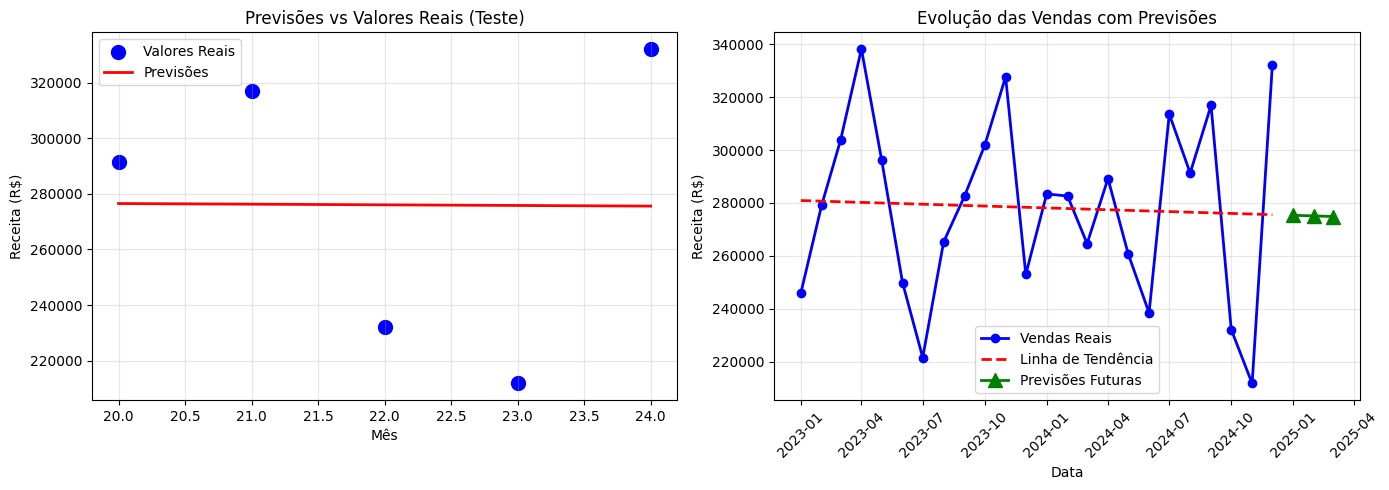


✅ Gráfico salvo como 'previsoes_vendas.png'


In [8]:
# Criar visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Previsões vs Real
axes[0].scatter(X_test, y_test, color='blue', label='Valores Reais', s=100)
axes[0].plot(X_test, y_pred_test, color='red', linewidth=2, label='Previsões')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Receita (R$)')
axes[0].set_title('Previsões vs Valores Reais (Teste)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Série temporal completa
dados_completos = pd.concat([df_mensal['Data'], y], axis=1)
dados_completos.columns = ['Data', 'Real']

# Criar previsões para todos os meses
previsoes_totais = modelo.predict(X)

axes[1].plot(dados_completos['Data'], dados_completos['Real'], 
             marker='o', linewidth=2, label='Vendas Reais', color='blue')
axes[1].plot(dados_completos['Data'], previsoes_totais, 
             linestyle='--', linewidth=2, label='Linha de Tendência', color='red')

# Adicionar previsões futuras
datas_futuras = pd.date_range(start=df_mensal['Data'].max() + pd.DateOffset(months=1), 
                              periods=3, freq='MS')
axes[1].plot(datas_futuras, previsoes_futuras, 
             marker='^', linewidth=2, label='Previsões Futuras', color='green', markersize=10)

axes[1].set_xlabel('Data')
axes[1].set_ylabel('Receita (R$)')
axes[1].set_title('Evolução das Vendas com Previsões')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../dashboard/previsoes_vendas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico salvo como 'previsoes_vendas.png'")


📅 SAZONALIDADE POR MÊS
Jan: R$ 264,652.60
Fev: R$ 280,914.31
Mar: R$ 284,180.43
Abr: R$ 313,700.37
Mai: R$ 278,512.85
Jun: R$ 244,191.91
Jul: R$ 267,576.94
Ago: R$ 278,281.74
Set: R$ 299,714.07
Out: R$ 266,946.72
Nov: R$ 269,721.97
Dez: R$ 292,527.43


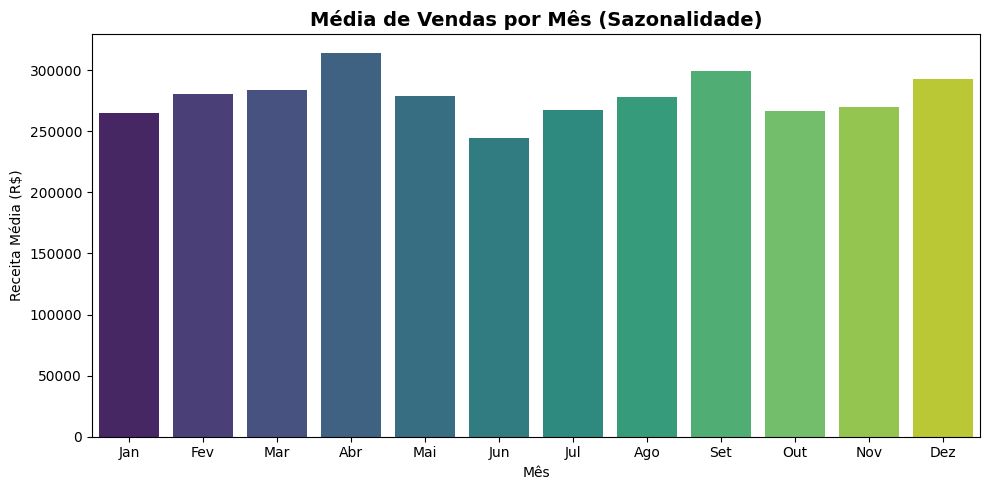

In [9]:
# Análise de sazonalidade por mês
df_mensal['Mes'] = df_mensal['Data'].dt.month
sazonalidade = df_mensal.groupby('Mes')['Receita_Total'].mean()

print("\n📅 SAZONALIDADE POR MÊS")
print("="*60)
for mes in range(1, 13):
    nome_mes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'][mes-1]
    print(f"{nome_mes}: R$ {sazonalidade[mes]:,.2f}")

# Gráfico de sazonalidade
plt.figure(figsize=(10, 5))
sns.barplot(x=sazonalidade.index, y=sazonalidade.values, palette='viridis')
plt.title('Média de Vendas por Mês (Sazonalidade)', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Receita Média (R$)')
plt.xticks(range(12), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                        'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.tight_layout()
plt.savefig('../dashboard/sazonalidade_mensal.png', dpi=300, bbox_inches='tight')
plt.show()